# Eksperiment 2-5 — Forma (EMA 33%)



In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from experiment_utils import save_result_v1, run_one_experiment, run, MLPClassifier

In [2]:
FEATURE_COLS = ["home_form_ema33", "away_form_ema33"]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")
data = data.dropna(subset=FEATURE_COLS + ["result"])

X = data[FEATURE_COLS].values.astype(np.float32)
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))

Train size: 888 Test size: 222


In [4]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0047 | val loss = 0.9108 | val acc = 0.5843
Epoch 100/1000 | train loss = 0.9987 | val loss = 0.9173 | val acc = 0.5955
Epoch 150/1000 | train loss = 0.9877 | val loss = 0.9135 | val acc = 0.5899
Epoch 200/1000 | train loss = 0.9878 | val loss = 0.9161 | val acc = 0.5955
Epoch 250/1000 | train loss = 0.9992 | val loss = 0.9171 | val acc = 0.6124
Epoch 300/1000 | train loss = 0.9934 | val loss = 0.9177 | val acc = 0.6011
Epoch 350/1000 | train loss = 0.9841 | val loss = 0.9118 | val acc = 0.6124
Epoch 400/1000 | train loss = 0.9840 | val loss = 0.9146 | val acc = 0.6067
Epoch 450/1000 | train loss = 0.9789 | val loss = 0.9109 | val acc = 0.6124
Epoch 500/1000 | train loss = 0.9836 | val loss = 0.9092 | val acc = 0.6124
Epoch 550/1000 | train loss = 0.9805 | val loss = 0.9153 | val acc = 0.6067
Epoch 600/1000 | train loss = 0.9737 | val loss = 0.9167 | val acc = 0.6067
Epoch 650/1000 | train loss = 0.9793 | val loss = 0.9180 | val acc = 0.6124
Epoch 700/100

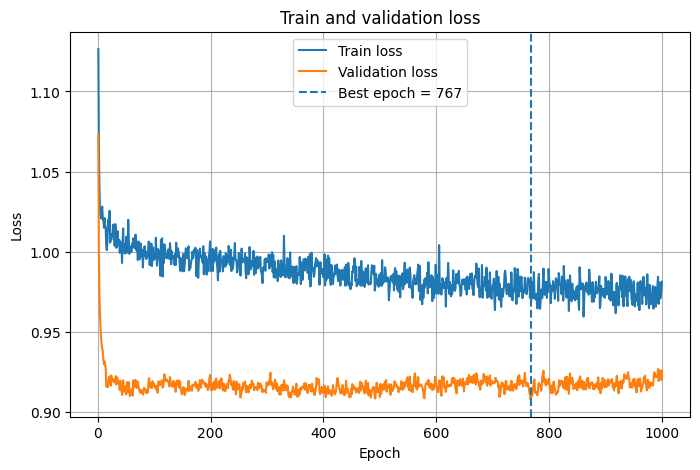

0.527027027027027

In [5]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [6]:
best_num_epochs = 767

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5270 | Precision: 0.3590 | Recall: 0.4351 | Specificity: 0.7188 | F1: 0.3703

Run 2/10
Accuracy: 0.5270 | Precision: 0.3634 | Recall: 0.4351 | Specificity: 0.7180 | F1: 0.3711

Run 3/10
Accuracy: 0.5315 | Precision: 0.3619 | Recall: 0.4468 | Specificity: 0.7232 | F1: 0.3827

Run 4/10
Accuracy: 0.5225 | Precision: 0.3457 | Recall: 0.4347 | Specificity: 0.7192 | F1: 0.3688

Run 5/10
Accuracy: 0.5405 | Precision: 0.3793 | Recall: 0.4505 | Specificity: 0.7256 | F1: 0.3872

Run 6/10
Accuracy: 0.5270 | Precision: 0.3475 | Recall: 0.4380 | Specificity: 0.7220 | F1: 0.3712

Run 7/10
Accuracy: 0.5360 | Precision: 0.3687 | Recall: 0.4472 | Specificity: 0.7244 | F1: 0.3830

Run 8/10
Accuracy: 0.5360 | Precision: 0.3701 | Recall: 0.4444 | Specificity: 0.7236 | F1: 0.3799

Run 9/10
Accuracy: 0.5315 | Precision: 0.3640 | Recall: 0.4412 | Specificity: 0.7216 | F1: 0.3767

Run 10/10
Accuracy: 0.5360 | Precision: 0.3701 | Recall: 0.4444 | Specificity: 0.7236 | F1: 0.3799

Summary o

In [7]:
save_result_v1(
    experiment_name="Experiment_2-5_EMA33",
    summary=summary
)


Saved result for Experiment_2-5_EMA33
File: ../results/experiment_summary_v1.csv
